### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons: less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd




### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [43]:
data = pd.read_csv('data/coupons.csv')

In [44]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [45]:
data.isna().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

Ratio of missing values:
car    0.991485
dtype: float64


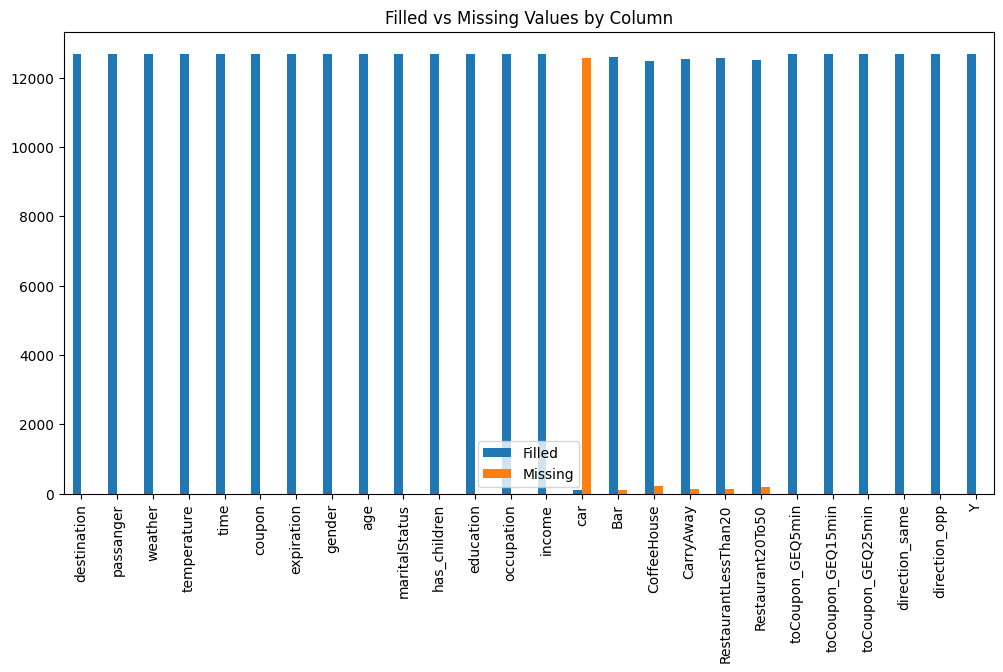

In [46]:
missing = data.isna().sum()
filled = data.notna().sum()

comparison = pd.DataFrame({
    "Filled": filled,
    "Missing": missing,
})
comparison.plot(kind="bar", figsize=(12, 6))
plt.title('Filled vs Missing Values by Column')
print("Ratio of missing values:")
print(data[["car"]].isna().mean())


<span style="color:blue"> Based on the graph above, I think it makes sense to remove the `Car` column entirly and remove the nan rows of other coulmns. </span>


3. Decide what to do about your missing data -- drop, replace, other...

In [47]:
cleaned_data = data.drop("car", axis=1)
cleaned_data = cleaned_data.dropna()
cleaned_data["age"] = pd.to_numeric(cleaned_data["age"], errors="coerce")

4. What proportion of the total observations chose to accept the coupon?



In [48]:
cleaned_data["Y"].mean() * 100

np.float64(56.93352098683666)

5. Use a bar plot to visualize the `coupon` column.

Text(0.5, 1.0, 'Coupon column distribution')

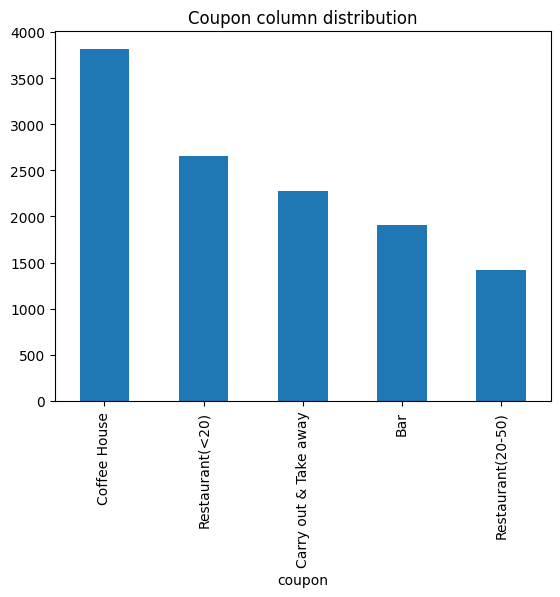

In [49]:
cleaned_data["coupon"].value_counts().plot(kind="bar")
plt.title("Coupon column distribution")

6. Use a histogram to visualize the temperature column.

Text(0, 0.5, 'Frequency')

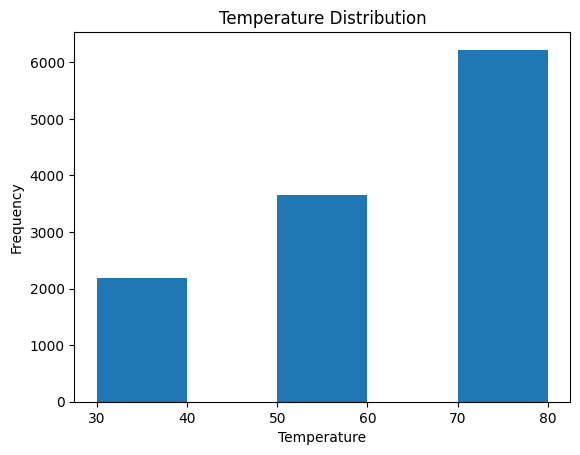

In [50]:
plt.hist(cleaned_data["temperature"], bins=5)
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [51]:
bar_coupons = cleaned_data[cleaned_data["coupon"] == "Bar"]
bar_coupons.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21.0,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21.0,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21.0,Single,...,less1,4~8,4~8,less1,1,1,1,0,1,1
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46.0,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,0
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46.0,Single,...,4~8,1~3,1~3,never,1,0,0,1,0,0


2. What proportion of bar coupons were accepted?


In [52]:
bar_coupons["Y"].mean() * 100

np.float64(41.19184526921067)

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


Text(0.5, 1.0, 'Regulars vs Frequent visitors')

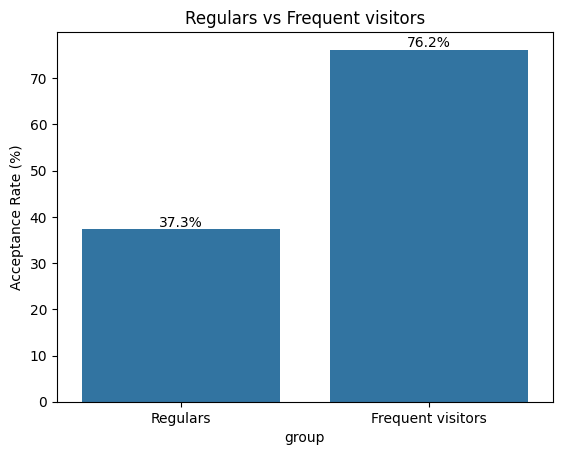

In [53]:
mask = bar_coupons["Bar"].isin(["4~8", "gt8"])
frequent_bar_visitors = bar_coupons[mask]
infrequent_bar_visitors = bar_coupons[~mask]

acceptance_df = pd.DataFrame({
    "group": ["Regulars", "Frequent visitors"],
    "acceptance_rate": [
        infrequent_bar_visitors["Y"].mean() * 100,
        frequent_bar_visitors["Y"].mean() * 100
    ]
})

ax = sns.barplot(
    data=acceptance_df,
    x="group",
    y="acceptance_rate"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Acceptance Rate (%)")
plt.title("Regulars vs Frequent visitors")


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


Text(0.5, 1.0, 'Regulars older 25y.o vs others')

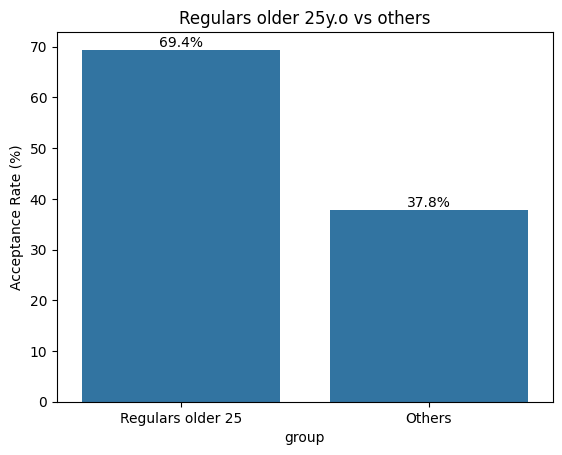

In [54]:
older25_regulars = bar_coupons[(bar_coupons["Bar"].isin(["1~3", "4~8", "gt8"])) & (bar_coupons["age"] > 25)]
others = bar_coupons[(bar_coupons["Bar"].isin(["never", "less1"])) & (bar_coupons["age"] <= 25)]

acceptance_df = pd.DataFrame({
    "group": ["Regulars older 25", "Others"],
    "acceptance_rate": [
        older25_regulars["Y"].mean() * 100,
        others["Y"].mean() * 100
    ]
})

ax = sns.barplot(
    data=acceptance_df,
    x="group",
    y="acceptance_rate"
)

# Add numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Acceptance Rate (%)")
plt.title("Regulars older 25y.o vs others")

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


Text(0.5, 1.0, 'Regulars with adult passengers not in agri sector vs others')

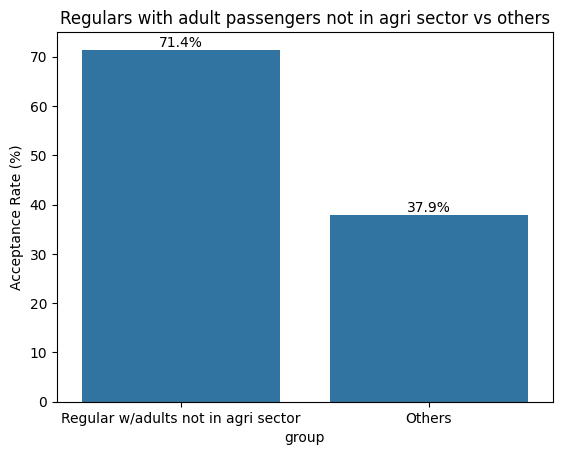

In [55]:
mask = (
    bar_coupons["Bar"].isin(["1~3", "4~8", "gt8"]) &
    bar_coupons["passanger"].isin(["Friend(s)", "Partner"]) &
    (bar_coupons["occupation"] != "Farming Fishing & Forestry")
)
bar_regular_no_kids_non_agri = bar_coupons[mask]
others = bar_coupons[~mask]

acceptance_df = pd.DataFrame({
    "group": ["Regular w/adults not in agri sector", "Others"],
    "acceptance_rate": [
        bar_coupons[mask]["Y"].mean() * 100,
        bar_coupons[~mask]["Y"].mean() * 100
    ]
})

ax = sns.barplot(
    data=acceptance_df,
    x="group",
    y="acceptance_rate"
)

# Add numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Acceptance Rate (%)")
plt.title("Regulars with adult passengers not in agri sector vs others")

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



Text(0.5, 1.0, 'Not widowed regulars with adult passengers vs others')

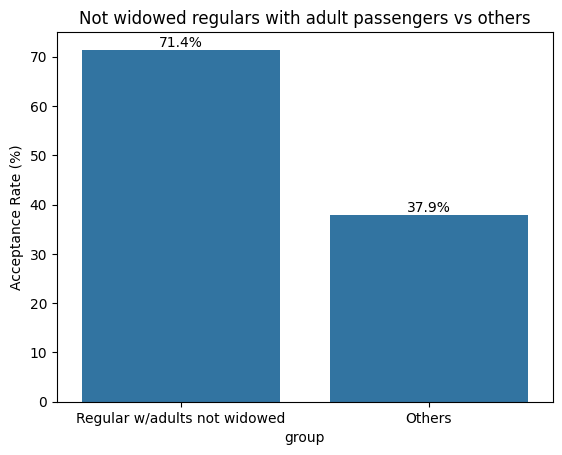

In [56]:
mask = (
    bar_coupons["Bar"].isin(["1~3", "4~8", "gt8"]) &
    bar_coupons["passanger"].isin(["Friend(s)", "Partner"]) &
    (bar_coupons["maritalStatus"] != "Widowed")
)
bar_regular_not_widowed_with_passengers = bar_coupons[mask]
others = bar_coupons[~mask]

acceptance_df = pd.DataFrame({
    "group": ["Regular w/adults not widowed", "Others"],
    "acceptance_rate": [
        bar_coupons[mask]["Y"].mean() * 100,
        bar_coupons[~mask]["Y"].mean() * 100
    ]
})

ax = sns.barplot(
    data=acceptance_df,
    x="group",
    y="acceptance_rate"
)

# Add numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Acceptance Rate (%)")
plt.title("Not widowed regulars with adult passengers vs others")

Text(0.5, 1.0, 'Under 30 y.o regulars vs others')

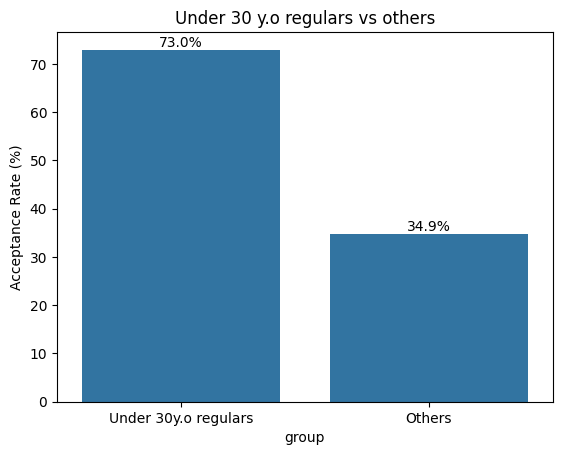

In [57]:
mask = (
    bar_coupons["Bar"].isin(["1~3", "4~8", "gt8"]) &
    (bar_coupons["age"] < 30)
)
bar_regular_under_30 = bar_coupons[mask]
others = bar_coupons[~mask]

acceptance_df = pd.DataFrame({
    "group": ["Under 30y.o regulars", "Others"],
    "acceptance_rate": [
        bar_coupons[mask]["Y"].mean() * 100,
        bar_coupons[~mask]["Y"].mean() * 100
    ]
})

ax = sns.barplot(
    data=acceptance_df,
    x="group",
    y="acceptance_rate"
)

# Add numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Acceptance Rate (%)")
plt.title("Under 30 y.o regulars vs others")


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

## <span style="color:blue"> Bar Coupon Acceptance Rate Analysis </span>

**41% of bar coupons were accepted.**

Drivers who visit bars more than 3 times per month are approximately 2 times more likely to accept the bar coupon compared to others.

Drivers who are older than 25 years old and visit bars at least once per month are also approximately 2 times more likely to accept the bar coupon.

Regular bar visitors who are driving with an adult passenger and whose occupation does not include agriculture (farming, forestry, fishing) are approximately 2 times more likely to accept bar coupons.

Approximately the same acceptance rate is observed for regular bar visitors who are driving with adult passengers and who are not widowed.
General conclusion:

The acceptance rate of bar coupons is higher among drivers who:

- visit bars more than 3 times per month
- are between 25–30 years old
- are not employed in agriculture
- have adult passengers
- are not widowed



### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.

## <span style="color:blue"> Coffee House Coupon Analysis </span>
First I will filter out data for cofee house coupons

In [58]:
coffee_coupon = cleaned_data[cleaned_data["coupon"] == "Coffee House"]

## Acceptance rate of the coffee house coupons

In [59]:
print(f"Acceptance rate of coffee house coupons: {coffee_coupon["Y"].mean() * 100}%")

Acceptance rate of coffee house coupons: 49.63312368972746%


We see that acceptance rate of the coupons is almost 50%

Now let's see the difference between acceptance rate between those who visit c.h at least 1/month or more and all others and let's call them `coffee_house_regulars`

## Acceptance rate between coffee house regulars vs others

Text(0.5, 1.0, 'Coffee House Coupon Acceptance by regulars vs non-regulars')

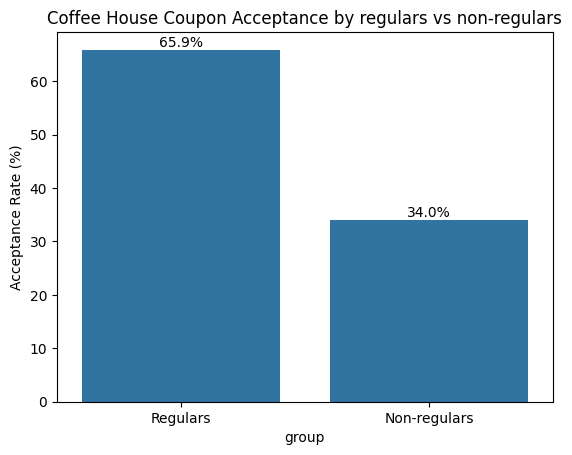

In [60]:
mask = coffee_coupon["CoffeeHouse"].isin(["1~3", "4~8", "gt8"])
coffee_regulars = coffee_coupon[mask]

acceptance_df = pd.DataFrame({
    "group": ["Regulars", "Non-regulars"],
    "acceptance_rate": [
        coffee_coupon[mask]["Y"].mean() * 100,
        coffee_coupon[~mask]["Y"].mean() * 100
    ]
})

ax = sns.barplot(
    data=acceptance_df,
    x="group",
    y="acceptance_rate"
)

# Add numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Acceptance Rate (%)")
plt.title("Coffee House Coupon Acceptance by regulars vs non-regulars")


We can see that drivers who visit coffee houses at least 1/month are almost twice likely to accpet the coupons.

Now let's investigate what was the acceptance rate for the people who were on their way to work in the morning and compare with others.

## Acceptance rate by depending on time and destination

Text(0.5, 1.0, 'Coffee House Coupon Acceptance by morning work commuters vs others')

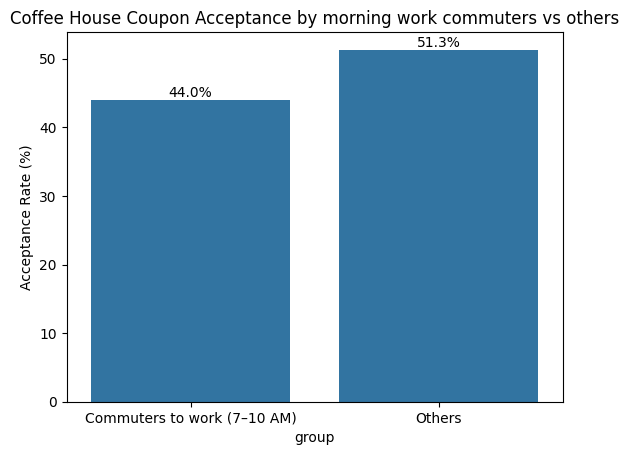

In [61]:
mask = ((coffee_coupon["destination"] == "Work") &
        (coffee_coupon["time"].isin(["7AM", "10AM"]))
       )
am_work_commuter = coffee_coupon[mask]
others = coffee_coupon[~mask]

acceptance_df = pd.DataFrame({
    "group": ["Commuters to work (7–10 AM)", "Others"],
    "acceptance_rate": [
        coffee_coupon[mask]["Y"].mean() * 100,
        coffee_coupon[~mask]["Y"].mean() * 100
    ]
})

ax = sns.barplot(
    data=acceptance_df,
    x="group",
    y="acceptance_rate"
)

# Add numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Acceptance Rate (%)")
plt.title("Coffee House Coupon Acceptance by morning work commuters vs others")

We can see from the above comparison, that people who are headed to work in the morning are slightly less likely to accept the coupon.

Let's check other grouop of people: young people (younger than 30) who don't have an urgent place to go and with adult passengers.

Text(0.5, 1.0, 'Young with passengers, no destination rush vs otherss')

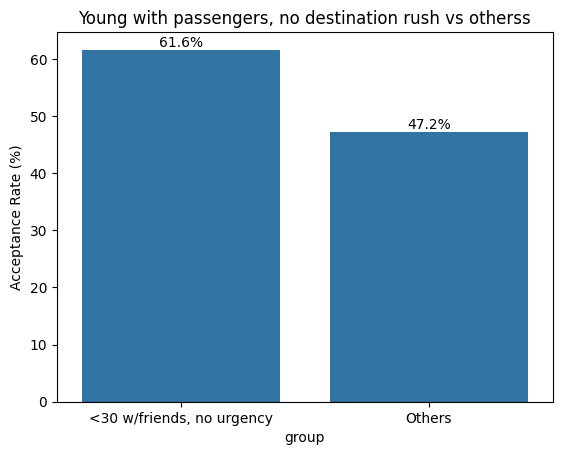

In [62]:
mask = ((coffee_coupon["destination"] == "No Urgent Place") &
        (coffee_coupon["age"] < 30) &
        (coffee_coupon["passanger"].isin(["Friend(s)", "Partner"]))
       )
home_or_nonurgent_with_kids = coffee_coupon[mask]
others = coffee_coupon[~mask]

acceptance_df = pd.DataFrame({
    "group": ["<30 w/friends, no urgency", "Others"],
    "acceptance_rate": [
        coffee_coupon[mask]["Y"].mean() * 100,
        coffee_coupon[~mask]["Y"].mean() * 100
    ]
})

ax = sns.barplot(
    data=acceptance_df,
    x="group",
    y="acceptance_rate"
)

# Add numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Acceptance Rate (%)")
plt.title("Young with passengers, no destination rush vs otherss")

After comparing different groups (such as people with kids going home, or people with kids walking without an urgent destination), I found that the distribution is more skewed for the group of young people who do not have an urgent place to go and are traveling with adult passengers. The acceptance rate is 1.5 times higher in this group than in others.




Let’s
take
into
consideration
drivers
who
visit
coffee
houses
more
than
three
times
a
month and examine
the
acceptance
rate
distribution
by
time
of
day.

<Axes: xlabel='time'>

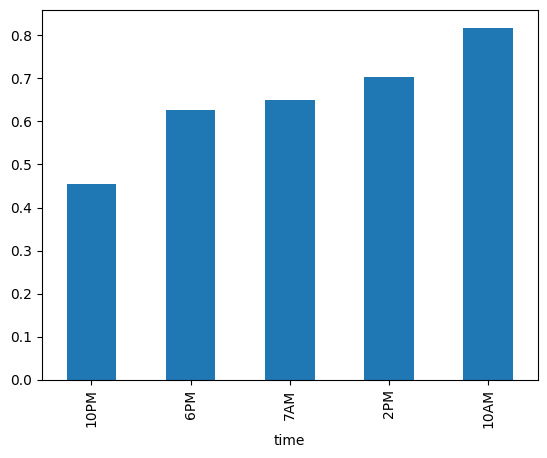

In [63]:
coffee_coupon[
    coffee_coupon["CoffeeHouse"].isin(["4~8", "gt8"])
].groupby("time")["Y"].mean().sort_values().plot(kind="bar")


It looks like visitors at 10 AM are more likely to accept the coupon. Taking this information into consideration, let’s examine the acceptance rate among frequent visitors at 10 AM who have passengers, and compare it with all other groups.

Text(0.5, 1.0, 'Frequent visitors (>3/month) with passengers at 10AM')

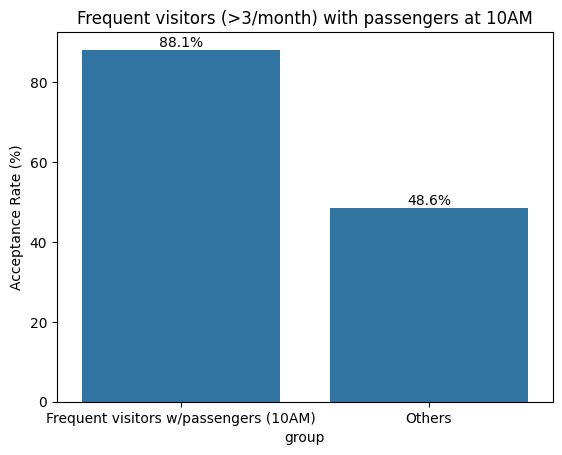

In [64]:
mask = ((coffee_coupon["CoffeeHouse"].isin(["4~8", "gt8"])) &
        (coffee_coupon["passanger"] != "Alone") &
        (coffee_coupon["time"] == "10AM")
       )

acceptance_df = pd.DataFrame({
    "group": ["Frequent visitors w/passengers (10AM)", "Others"],
    "acceptance_rate": [
        coffee_coupon[mask]["Y"].mean() * 100,
        coffee_coupon[~mask]["Y"].mean() * 100
    ]
})

ax = sns.barplot(
    data=acceptance_df,
    x="group",
    y="acceptance_rate"
)

# Add numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Acceptance Rate (%)")
plt.title("Frequent visitors (>3/month) with passengers at 10AM")


If we offer a coupon at 10 AM to people who visit coffee houses more than three times a month and have passengers, they are almost twice as likely to accept the coupon compared to others.

Text(0.5, 1.0, 'Female vs male frequent visitors')

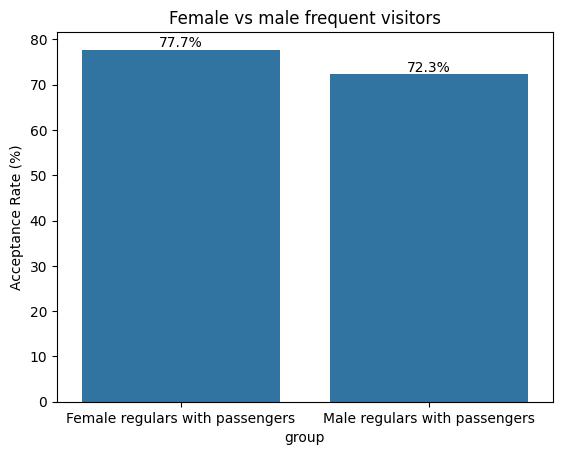

In [65]:
female_mask = ((coffee_regulars["gender"] == "Female") &
               (coffee_regulars["passanger"] != "Alone")
              )
male_mask = ((coffee_regulars["gender"] == "Male") &
             (coffee_regulars["passanger"] != "Alone")
             )
coffee_regulars["passanger"].value_counts()


acceptance_df = pd.DataFrame({
    "group": ["Female regulars with passengers", "Male regulars with passengers"],
    "acceptance_rate": [
        coffee_regulars[female_mask]["Y"].mean() * 100,
        coffee_regulars[male_mask]["Y"].mean() * 100
    ]
})

ax = sns.barplot(
    data=acceptance_df,
    x="group",
    y="acceptance_rate"
)

# Add numbers on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.ylabel("Acceptance Rate (%)")
plt.title("Female vs male frequent visitors")

The
analysis
did
not show
a
significant
difference
between
male and female
drivers in the
mentioned
category.

## Acceptance rate based on occupation

<Axes: xlabel='occupation'>

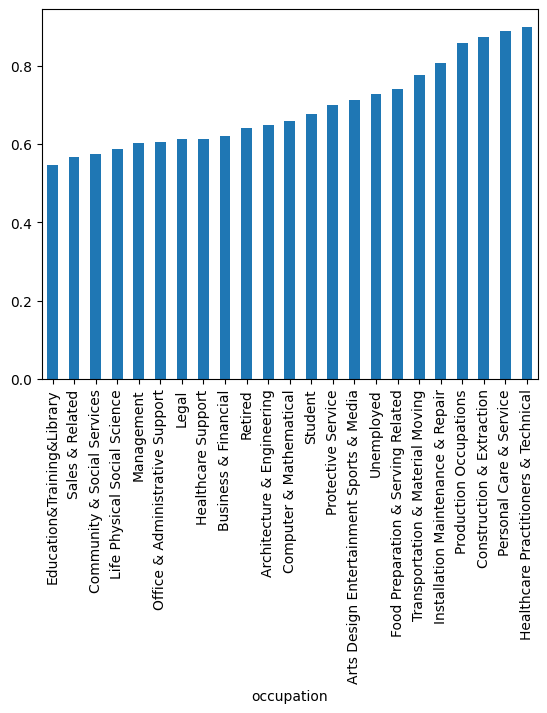

In [66]:
occupation_accep_rate = coffee_regulars.groupby("occupation")["Y"].mean().sort_values()
occupation_accep_rate.plot(kind="bar")

Healthcare workers have the highest acceptance rate.

While analyzing coffee house regulars only, I noticed that drivers working in **agriculture**, **construction**, and **building/grounds cleaning** occupations are not included in the category of regulars. The same applies to drivers with widowed marital status.

In [67]:
print(f"Occupations who got filtered out by having <1 frequency of c.h. visits: {set(coffee_coupon["occupation"]) - set(coffee_regulars["occupation"])}")
print(f"Marital status of people who got filtered out by having <1 frequency of c.h. visits {set(coffee_coupon["maritalStatus"]) - set(coffee_regulars["maritalStatus"])}")

Occupations who got filtered out by having <1 frequency of c.h. visits: {'Building & Grounds Cleaning & Maintenance', 'Farming Fishing & Forestry'}
Marital status of people who got filtered out by having <1 frequency of c.h. visits {'Widowed'}


## Acceptance rate depending on weather

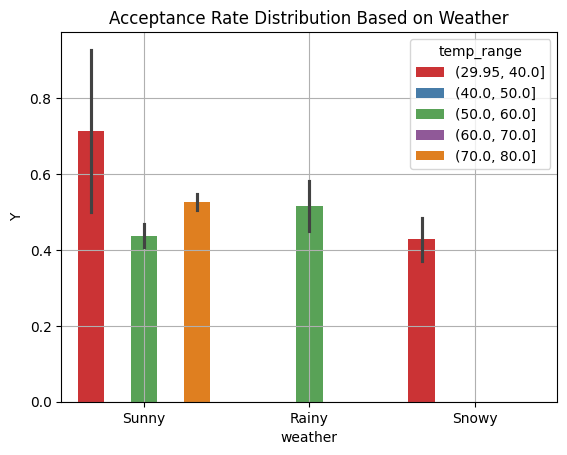

In [68]:
coffee_coupon["temp_range"] = pd.cut(
    coffee_coupon["temperature"],
    bins=5
)
ax = sns.barplot(data =coffee_coupon, x="weather", y="Y", estimator="mean", hue="temp_range", palette="Set1")
plt.title("Acceptance Rate Distribution Based on Weather")
ax.grid(True)


It looks like on sunny days people are slightly more inclined to accept the coupon, especially when the temperature is low.



## Acceptance rate based on the distance to the coffee house

In [69]:
only5min = coffee_coupon[(coffee_coupon["toCoupon_GEQ5min"] == 1) & (coffee_coupon["toCoupon_GEQ15min"] == 0) & (coffee_coupon["toCoupon_GEQ25min"] == 0)]
from5to15min = coffee_coupon[(coffee_coupon["toCoupon_GEQ5min"] == 1) | (coffee_coupon["toCoupon_GEQ15min"] == 1) & (coffee_coupon["toCoupon_GEQ25min"] == 0)]

from5to25min = coffee_coupon[(coffee_coupon["toCoupon_GEQ5min"] == 1) & (coffee_coupon["toCoupon_GEQ15min"] == 1) & (coffee_coupon["toCoupon_GEQ25min"] == 1)]



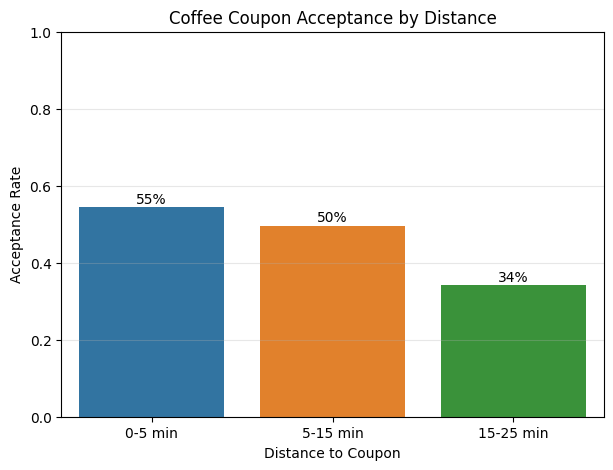

In [70]:
distance_accep = pd.DataFrame({
    "distance_group": [
        "0-5 min",
        "5-15 min",
        "15-25 min"
    ],
    "acceptance_rate": [
        only5min["Y"].mean(),
        from5to15min["Y"].mean(),
        from5to25min["Y"].mean()
    ]
})
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=distance_accep,
    x="distance_group",
    y="acceptance_rate",
    hue="distance_group",
)

# grid
ax.grid(axis="y", alpha=0.3)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.0%}",
        ha="center"
    )

plt.title("Coffee Coupon Acceptance by Distance")
plt.ylabel("Acceptance Rate")
plt.xlabel("Distance to Coupon")
plt.ylim(0, 1)

plt.show()

As expected, the closer the coffee house is, the more likely drivers are to accept the coupon.

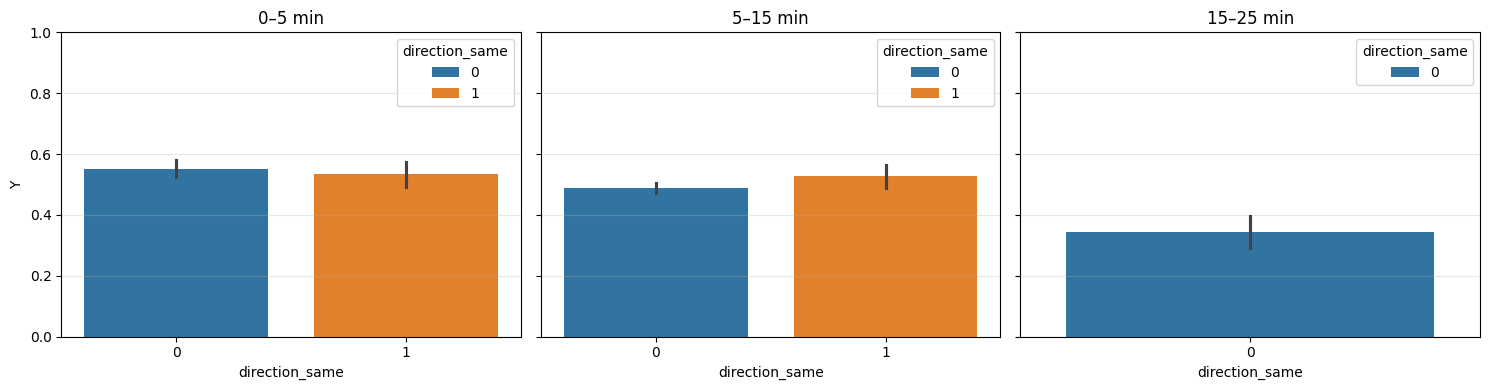

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
sns.barplot(
    data=only5min,
    x="direction_same",
    y="Y",
    estimator="mean",
    hue="direction_same",
    ax=axes[0],
)
axes[0].set_title("0–5 min")
sns.barplot(
    data=from5to15min,
    x="direction_same",
    y="Y",
    estimator="mean",
    hue="direction_same",
    ax=axes[1],
)
axes[1].set_title("5–15 min")
sns.barplot(
    data=from5to25min,
    x="direction_same",
    y="Y",
    estimator="mean",
    hue="direction_same",
    ax=axes[2],
)
axes[2].set_title("15–25 min")
for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

Here I wanted to examine how much the direction people are traveling influences their decision to accept a coupon. The 5–25 minute distance group, for some reason, does not include drivers heading in the same direction. For other distance groups, we do not see a significant difference in the distribution.

## Coffee House Coupon Acceptance Rate

**The acceptance rate of coffee house coupons is 50%.**

Coffee house regulars (at least 1/month) are more likely to accept a coupon than others:
- *Acceptance rate of c.h.c regulars: 66%*
- *Acceptance rate of c.h.c non-regulars: 34%*

The difference in acceptance rates between drivers who are on their way to work in the morning (7–10 AM) and visit coffee houses at least once per month is only slightly higher than the acceptance rate among all other drivers outside this category.
- *Acceptance rate of coffee house coupons by those who's on the way to work in the morning: 44.0 %*
- *Acceptance rate of coffee house coupon by c.h. regulars of all others: 51%*

People under 30 who don't have an urgent place to go and have adult passengers with them are 1.5 more likly to accpet a coupon.
- *Acceptance rate of coffee house coupons by younger than 30, not urgent destination and with adult passangers: 62%*
- *Acceptance rate of coffee house coupon by c.h. regulars of all others: 47%*

Drivers  are more likely to accept coffee house coupons on sunny and cool days, while snowy weather is associated with the lowest acceptance likelihood compared to sunny and rainy conditions.

Among coffee house regulars, healthcare employees demonstrated a higher coupon acceptance rate than people in other occupations.

Workers in agriculture-related occupations (farming, forestry, fishing), as well as building and grounds cleaning occupations, were not present in the group of coffee house regulars (drivers who visit coffee houses at least once per month).

Drivers with widowed marital status were also absent from the list of coffee house regulars.

Female drivers who are coffee house regulars and are traveling with adult passengers are slightly more likely to accept coffee house coupons than male drivers in the same category.
- *Acceptance rate of coffee house coupons by female drivers with adult passangers among c.h. regulars: 78%*
- *Acceptance rate of coffee house coupons by male drivers with adult passangers among c.h. regulars: 72%*

Frequent coffee house visitors (more than 3 visits per month) are almost twice as likely to accept coupons at 10 AM while traveling with passengers compared to all other drivers.
- *Acceptance rate of c.h. coupon by those who visit c.h. >4/month and have passanegers, at 10 am: 88%*
- *All others: 48%*

**General Conclusion**

Coffee house coupon acceptance is higher among:

Regular coffee house visitors (at least 1/month, especially >3/month)
 - Drivers traveling with passengers
 - Drivers traveling during the morning hours (7–10 AM), especially 10AM, but not to work.
 - Drivers in healthcare occupations
 - Drivers in sunny weather conditions
 - Female drivers have slightly larger acceptance rate than male drivers
 - Drivers under 30 y.o with adult passengers and having no urgent destination are 1.5 more likely to accept the coupon.

Acceptance is lower among:

 - Drivers in snowy weather
 - Drivers outside the regular coffee house visitor segment
  - Drivers going to work in the morning
